Problem Statement:
------------------
The objective of this project is to build a machine learning model that can predict the category (label) assigned to user comments based on textual content and metadata features.

The dataset contains:
- User comments (textual data)
- Interaction signals (upvotes, downvotes,if_1,if_2)
- Emoticon usage (emoticon_1,emoticon_2,emoticon_3)
- Demographic indicators (race,religion,gender,disability)
- Temporal information (created_date)
- Post-level metadata (post_id)

Goal:
-----
Develop and compare multiple machine learning models and achieve an accuracy score greater than 0.80.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import RandomizedSearchCV
import lightgbm as lgb
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

numpy - numerical computations & array operations

pandas - handling & manipulating dataset such as reading csv and performing data analysis

Matplotlib & Seaborn - data visualization, where Matplotlib provides basic plotting and Seaborn helps in creating more advanced and visually appealing graphs.

From Sklearn - Imported train_test_split to divide the dataset into training and validation sets.

StandardScaler to normalize numerical features. MinMaxscaler to scale features into specified range

TfidfVectorizer to convert text data into numerical features for machine learning models.

At last Seaborn style to 'whitegrid' to improve the visual appearance of plots.

In [3]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/comment-category-prediction-challenge/Sample.csv
/kaggle/input/competitions/comment-category-prediction-challenge/train.csv
/kaggle/input/competitions/comment-category-prediction-challenge/test.csv


In [4]:
DATA_PATH = '/kaggle/input/competitions/comment-category-prediction-challenge'

In [5]:
train = pd.read_csv(f'{DATA_PATH}/train.csv')
test  = pd.read_csv(f'{DATA_PATH}/test.csv')
sample  = pd.read_csv(f'{DATA_PATH}/Sample.csv')

In [6]:
train.columns

Index(['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3',
       'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender',
       'disability', 'comment', 'label'],
      dtype='object')

In [7]:
train['religion'].unique()

array([nan, 'christian', 'muslim', 'none', 'jewish', 'atheist', 'other',
       'hindu', 'buddhist'], dtype=object)

In [8]:
train['religion'] = train['religion'].replace('none','other')

In [9]:
train['religion'] = train['religion'].fillna('other')

In [10]:
train['religion'].unique()

array(['other', 'christian', 'muslim', 'jewish', 'atheist', 'hindu',
       'buddhist'], dtype=object)

In [11]:
print('Train shape:', train.shape)
print('Test shape:', test.shape)

Train shape: (198000, 15)
Test shape: (102000, 14)


test have 1 less column because we have to guess it. 

In [12]:
train.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,other,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,other,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,other,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,other,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,other,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


In [13]:
test.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment
0,2024-02-08 13:13:27.998156+00:00,72,2,0,0,4,1,0,10,NaN,NaN,NaN,False,Canada is being run by someone with the mental...
1,2024-03-01 23:33:25.547123+00:00,123,0,0,0,0,0,0,10,NaN,NaN,NaN,False,And your comment is left-wing drivel
2,2024-02-09 21:52:48.426303+00:00,120,0,0,0,3,0,0,4,NaN,NaN,NaN,False,http://talkingpointsmemo..com/dc/special-couns...
3,2024-02-17 03:43:02.980294+00:00,123,0,0,0,0,0,0,4,NaN,NaN,NaN,False,"Trump jl Blames: The Secret Service, James Com..."
4,2024-04-24 02:27:57.145155+00:00,123,0,0,0,0,0,0,11,NaN,NaN,NaN,False,It was hard enough to get the stench out of th...


In [14]:
sample.head()

,ID,label
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0


# **MILESTONE-1**# 

In [15]:
print('Train shape:', train.shape)

Train shape: (198000, 15)


In [16]:
print('Test shape:', test.shape)

Test shape: (102000, 14)


In [17]:
object_columns = train.select_dtypes(include='object').columns
len(object_columns)

5

In [18]:
object_columns

Index(['created_date', 'race', 'religion', 'gender', 'comment'], dtype='object')

In [19]:
num_columns = train.select_dtypes(include=['int64', 'float64']).columns
len(num_columns)

9

In [20]:
num_columns

Index(['post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote',
       'downvote', 'if_1', 'if_2', 'label'],
      dtype='object')

In [21]:
train.dtypes

created_date    object
post_id          int64
emoticon_1       int64
emoticon_2       int64
emoticon_3       int64
upvote           int64
downvote         int64
if_1             int64
if_2             int64
race            object
religion        object
gender          object
disability        bool
comment         object
label            int64
dtype: object

In [22]:
missing_values = train.isnull().sum()
missing_values[missing_values > 0]

race       145423
gender     145423
comment         1
dtype: int64

For the demographic columns with massive missingness, I treated them as effectively unavailable - they are not used as features in the model. For the single missing comment, I filled it with an empty string.

In [23]:
train['label'].nunique()

4

In [24]:
label_distribution = train['label'].value_counts(normalize=True) * 100
label_distribution

label
0    57.663131
2    31.535354
1     8.039394
3     2.762121
Name: proportion, dtype: float64

This class imbalance means the model might become biased toward predicting label 0, so I have to be careful with evaluation.

In [25]:
train['upvote'].median()

1.0

In [26]:
train[['upvote','downvote','if_1','if_2']].max()

upvote       201
downvote     107
if_1        1860
if_2        1833
dtype: int64

In [27]:
train['if_2'].min()

3

# MILESTONE-2

In [28]:
# Convert to datetime
train['created_date'] = pd.to_datetime(train['created_date'])

# Extract month name in lowercase
train['month'] = train['created_date'].dt.month_name().str.lower()

# Find most frequent month
train['month'].value_counts().head(1)

month
may    23573
Name: count, dtype: int64

In [29]:
train['total_emoticons'] = (
    train['emoticon_1'] +
    train['emoticon_2'] +
    train['emoticon_3']
)

train['total_emoticons'].max()

60

In [30]:
train['comment'] = train['comment'].fillna('')

# Character length including spaces
train['char_length'] = train['comment'].apply(len)

# Median for label 3
train[train['label'] == 3]['char_length'].median()

128.0

By this question we got to know that we can fill empty comment by empty string only. We can use other simpleimputer to handle missing values by replacing it with statistical value like mean, median. 

In [31]:
min_upvote = train['upvote'].min()
max_upvote = train['upvote'].max()

scaled_value_10 = (10 - min_upvote) / (max_upvote - min_upvote)
scaled_value_10

0.04975124378109453

In [32]:
# average word count for label 1
train['word_count'] = train['comment'].apply(lambda x: len(str(x).split()))

round(train[train['label'] == 1]['word_count'].mean(), 2)

np.float64(57.23)

In [33]:
# trump politics
train['comment'].str.contains("Trump", case=False, na=False).sum()

np.int64(24398)

In [34]:
import string

# Given stopwords
custom_stopwords = [
'a','an','the','and','or','but','if','because','as','of','at','by','for',
'with','about','to','from','up','on','in','out','over','under','is','are',
'was','were','be','been','being','have','has','had','do','does','did','it',
'its','they','them','their','she','her','he','him','his','this','that',
'which','who','whom','i','me','my','we','our','you','your'
]

# Get first comment
text = train.loc[0, 'comment']

# Remove punctuation
text_no_punct = text.translate(str.maketrans('', '', string.punctuation))

# Convert to lowercase & split
tokens = text_no_punct.lower().split()

# Remove stopwords
filtered_tokens = [word for word in tokens if word not in custom_stopwords]

len(filtered_tokens)

12

In [35]:
unique_tokens = set()

for text in train['comment'].fillna('').str.lower():
    unique_tokens.update(text.split())

len(unique_tokens)

425413

In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words='english',
    min_df=5,
    ngram_range=(1,2)
)

X_tfidf = tfidf.fit_transform(train['comment'])

X_tfidf.shape

(198000, 132974)

min_df = 5

This parameter tells the model to ignore words that appear in fewer than 5 documents

ngram_range=(1,2) - captures both single words and word pairs

Example

"this is good"

Unigrams - this, is, good

Bigrams - this is, is good

# Milestone-Based Exploratory Insights

As part of the project milestones, several exploratory questions were investigated to better understand the dataset. These questions helped uncover key characteristics of the data such as dataset size, feature types, missing values, and text statistics. In the following section, we summarize the findings from Milestone 1 and Milestone 2, which provide additional insights into the structure and properties of the dataset.

# Insights from Milestone-1: Dataset Overview
The first milestone focuses on understanding the basic structure and properties of the dataset. The analysis provides insights into dataset size, feature types, missing values, and the distribution of the target variable.

**Dataset Size**

The training dataset contains 198,000 observations and 15 features, while the test dataset contains 102,000 observations with 14 features. The difference in feature count is expected since the test dataset does not contain the target variable (label).

**Feature Types**

The dataset contains a mix of numerical, categorical, and textual features:

* 5 object-type columns: created_date, race, religion, gender, and comment
* 9 numerical columns including interaction metrics (upvote, downvote), emoticon indicators, and other numeric flags
* 1 boolean column: disability

This mixture of feature types suggests that the modeling pipeline will need to handle text processing, categorical encoding, and numerical scaling.

**Missing Values**

Several columns contain missing values:

* race, religion, and gender each contain 145,423 missing values

* The comment column contains 1 missing value

The large number of missing demographic attributes indicates that appropriate imputation strategies will be necessary during preprocessing.

**Target Variable Distribution**

The dataset contains 4 distinct target classes. The class distribution is highly imbalanced:

Label Percentage - 

0      ~    57.66% 
2      ~    31.53% 
1      ~    8.04% 
3      ~    2.76%

This indicates that Label 0 dominates the dataset, while Labels 1 and 3 appear significantly less frequently. Class imbalance can affect model performance and it will require careful evaluation during training.

**Engagement Features**

* The median number of upvotes per comment is 1, indicating that most comments receive relatively low engagement.

Among the engagement-related features:

* if_1 has the largest maximum value (1860) compared to other numerical features.

* The minimum value of if_2 is 3, suggesting the feature may represent a count-based or threshold metric.

**Summary**

> Overall, the dataset contains a diverse mix of textual, numerical, and categorical information, with notable class imbalance and missing demographic data. These characteristics highlight the importance of text feature extraction, proper handling of missing values, and robust modeling techniques in the subsequent stages of the project.

# Insights from Milestone-2: Text and Feature Analysis

The second milestone focuses on deeper exploration of textual data and additional feature engineering insights. These analyses help better understand the structure, scale, and characteristics of the comment dataset.

**Temporal Patterns**

After converting the created_date column into a datetime format, the month of May appears most frequently in the dataset, with 23,573 comments.
This indicates that user activity or comment generation was highest during this period.

**Emoticon Usage**

A new feature called total_emoticons was created by summing the three emoticon-related variables (emoticon_1, emoticon_2, and emoticon_3).
The maximum observed value is 60, suggesting that some comments contain a very high number of emoticon signals.

**Comment Length Analysis**

After treating missing comments as empty strings, the median character length of comments belonging to label 3 is 128 characters.
This suggests that comments in this category tend to be relatively longer compared to typical short comments.

**Engagement Feature Scaling**

When applying Min-Max scaling to the upvote column, a comment with 10 upvotes corresponds to a normalized value of approximately 0.0498.
This indicates that the upvote distribution is relatively wide, with values extending well beyond 10.

**Word Count Statistics**

The average word count for comments labeled as category 1 is approximately 57.23 words.
This suggests that comments in this category tend to contain relatively detailed textual content.

**Text Cleaning Example**

After removing punctuation and filtering out common stopwords from the first comment in the dataset, 12 meaningful words remain.
This demonstrates how text preprocessing reduces noise and focuses on informative tokens.

**Vocabulary Size**

After converting all comments to lowercase and tokenizing based on whitespace, the dataset contains 425,413 unique tokens.
This highlights the very large vocabulary size present in the comment dataset.

**TF-IDF Feature Space**

Applying TF-IDF vectorization with stop_words='english', min_df=5, and ngram_range=(1,2) produces 132,974 textual features.
This high-dimensional feature space reflects the complexity and diversity of language used in the comments.

**Summary**

Overall, the Milestone-2 analysis highlights several important characteristics of the dataset:

* The dataset contains extremely diverse textual vocabulary

* Comments vary widely in length and structure

* Certain keywords appear frequently, indicating topic concentration

* Textual features are likely to play a critical role in model performance

* These findings justify the use of advanced text feature extraction methods such as TF-IDF vectorization in the modeling stage.

# Exploratory Data Analysis (EDA)

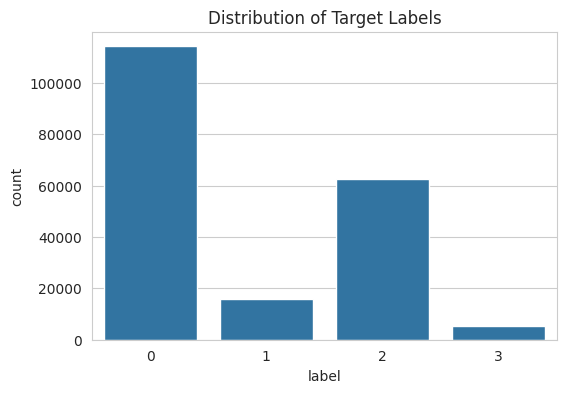

In [37]:
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=train)
plt.title("Distribution of Target Labels")
plt.show()

**Insight: Target Label Distribution**

* The distribution of the target variable shows that label 0 is the most frequent class, followed by label 2.

* Labels 1 and 3 appear significantly less often, indicating class imbalance in the dataset.

* Class imbalance may affect model training, as models may become biased toward predicting the majority class.

* Robust models like LightGBM can help mitigate this issue.

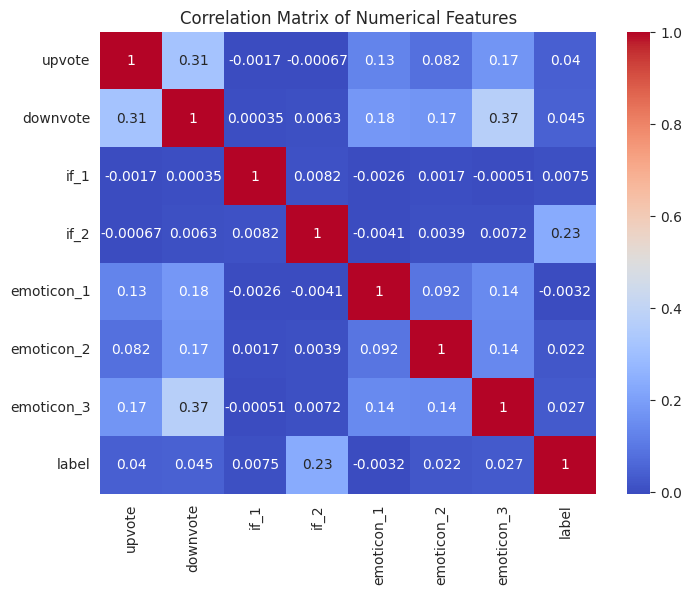

In [38]:
num_cols = ['upvote','downvote','if_1','if_2','emoticon_1','emoticon_2','emoticon_3']

plt.figure(figsize=(8,6))
sns.heatmap(train[num_cols + ['label']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of Numerical Features")
plt.show()

Correlation measures the relationship between two variables, i.e., how one variable changes with respect to another.

**Insight: Correlation Between Numerical Features and Target**

* The heatmap shows the pairwise correlation between numerical features and the target label.

* Most numerical features show very weak correlation with the target variable, indicating that no single feature strongly determines the label.

* Among the available features, if_2 shows the highest correlation with the label (~0.23), suggesting it may have some predictive importance.

* The features upvote and downvote show moderate correlation with each other (~0.31), which is expected since user engagement metrics often move together.

* The emoticon features (emoticon_1, emoticon_2, emoticon_3) show very low correlation with the target, indicating that emoticon usage alone may not strongly influence the comment category.

* Overall, the low correlations suggest that the model will likely rely more on textual features from the comment column rather than purely numerical metadata.

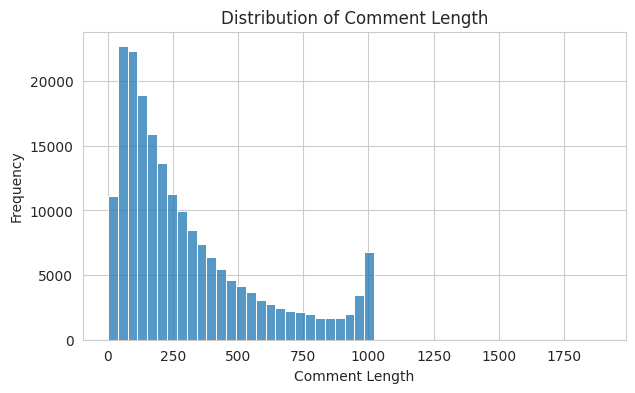

In [39]:
train['comment_length'] = train['comment'].fillna('').apply(len)

plt.figure(figsize=(7,4))
sns.histplot(train['comment_length'], bins=50)
plt.title("Distribution of Comment Length")
plt.xlabel("Comment Length")
plt.ylabel("Frequency")
plt.show()

In [40]:
train['comment_length'].max()

1892

If max length is 1892 ..then why we aren't able to see that in histogram?

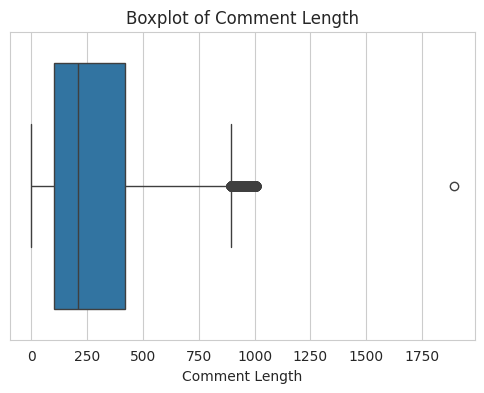

In [41]:
plt.figure(figsize=(6,4))
sns.boxplot(x=train['comment_length'])
plt.title("Boxplot of Comment Length")
plt.xlabel("Comment Length")
plt.show()

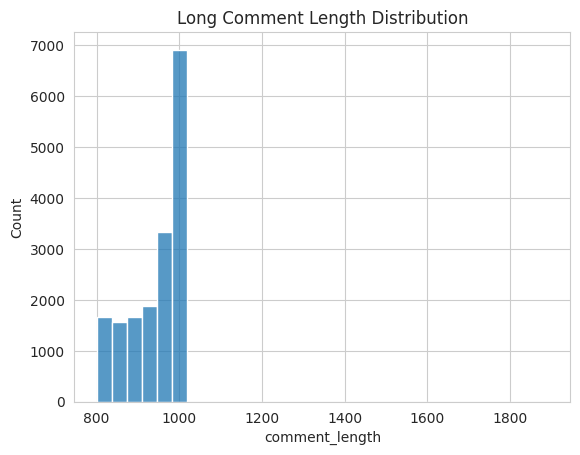

In [42]:
sns.histplot(train[train['comment_length'] > 800]['comment_length'], bins=30)
plt.title("Long Comment Length Distribution")
plt.show()

In [43]:
train[train['comment_length'] > 1500].shape

(1, 20)

In [44]:
train[train['comment_length'] > 1500]['comment'].values[0]

"As usual WW plumbing the depths for deeper meaning .... that is unless it involves an issue on which they disagree then it is ridicule 24/7.   Clever creating the Bundyland series complete with cartoon banner.  Set the tone for the level of journalism to expect ... journalism ?  ... fatastisticism. \n\nI did notice you soft pedaling the ridicule of David Fry identifying him as troubled.  My guess is that has more to do with sympathy for his pot smoking withdrawl rants than respect for his politics.  Respect is never a factor with liberals as evidenced by your series of vapid caricatures.  \n\nDid you happen to see the stories actual journalists did on Refuge mis-managment, fires, floods, and the millions of Carp that are harassing the birds away from the Bird Refuge?  The stories of arbitrary miss-management that are driving unemployment ever higher in eastern Oregon.  Curry County Sheriff turning in his badge in frustration for lack of resources dud to dwindling tax base engineered b

# Insights : Distribution of Comment Length
* The distribution of comment length is right-skewed, meaning that most comments are relatively short while only a few are extremely long.
* The median comment length is approximately 200 characters, suggesting that typical user comments tend to be concise.
* The majority of comments fall within the 100–400 character range, representing the central portion of the distribution.
* The maximum observed comment length is 1892 characters, indicating that the platform allows relatively long comments.
* Further inspection shows that only one comment exceeds 1500 characters, confirming that extremely long comments are rare and appear as outliers in the dataset.
* Although the maximum comment length reaches 1892 characters, such extremely long comments are rare.The histogram shows that the majority of comments fall within shorter length ranges, with only a small number of outliers forming the long right tail of the distribution.

Overall, this distribution highlights the variability in comment length and suggests that text-based feature extraction techniques such as TF-IDF are essential for capturing meaningful patterns within the comments.

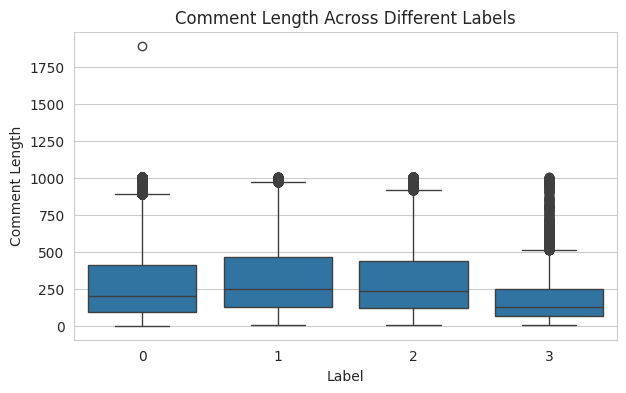

In [45]:
plt.figure(figsize=(7,4))
sns.boxplot(x='label', y='comment_length', data=train)

plt.title("Comment Length Across Different Labels")
plt.xlabel("Label")
plt.ylabel("Comment Length")

plt.show()

# Insight: Comment Length Across Different Labels

* The boxplot compares the distribution of comment lengths across the four label categories.

* The distributions for labels 0, 1, and 2 appear largely similar, with overlapping interquartile ranges and comparable median values.

* Label 3 shows slightly shorter comments on average, but the difference is not substantial.

* All categories contain long-comment outliers, indicating that very long comments appear across multiple classes.

Overall, the significant overlap between the distributions suggests that comment length alone is not a strong distinguishing feature for predicting the label. While it may contribute marginally as an auxiliary feature, the classification task will likely rely more heavily on the textual content of the comments rather than their length.

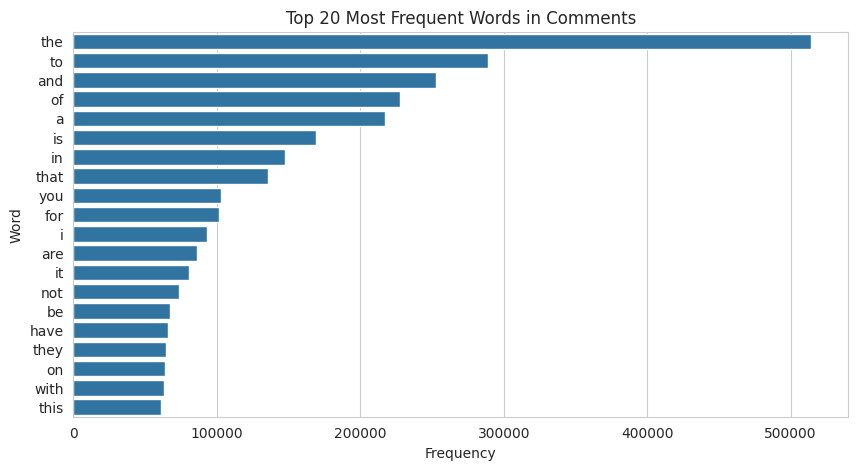

In [46]:
from collections import Counter

# Combine all comments
all_words = " ".join(train['comment'].fillna('').str.lower()).split()

# Count word frequency
word_counts = Counter(all_words)

# Convert to dataframe
top_words = pd.DataFrame(word_counts.most_common(20), columns=['word','count'])

# Plot
plt.figure(figsize=(10,5))
sns.barplot(x='count', y='word', data=top_words)

plt.title("Top 20 Most Frequent Words in Comments")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

The most common words include "the", "to", "and", "of", and "a", which are typical stopwords in English language text.

Since such words do not help distinguish between comment categories, they are typically removed or down-weighted during text preprocessing.

This observation supports the use of text preprocessing techniques such as stopword removal and TF-IDF vectorization, which help emphasize informative words while reducing the influence of very common terms.

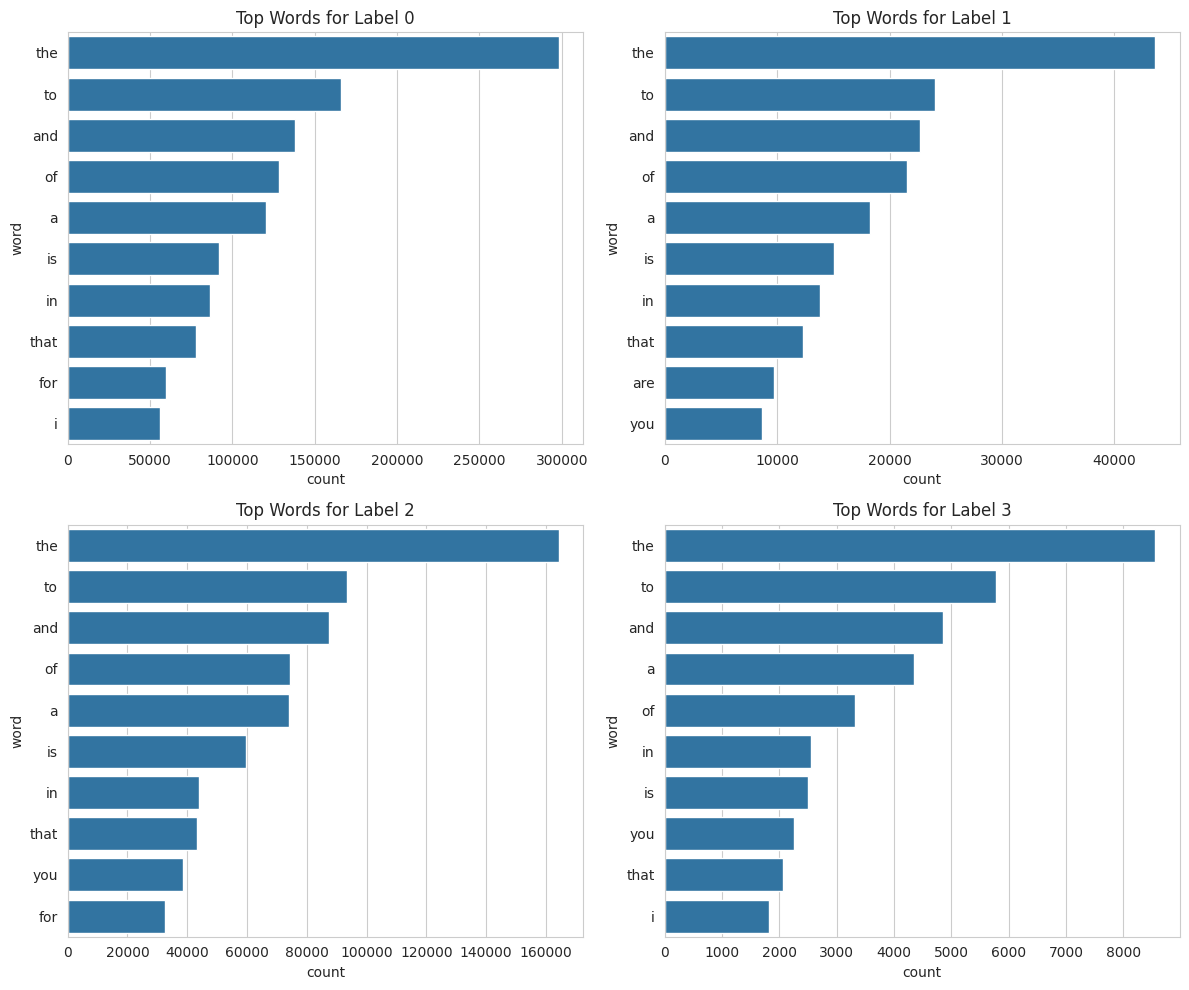

In [47]:
from collections import Counter


plt.figure(figsize=(12,10))

labels = sorted(train['label'].unique())

for i, label in enumerate(labels):

    
    text = " ".join(train[train['label'] == label]['comment'].fillna('').str.lower())
    
    
    words = text.split()
    
    
    word_counts = Counter(words).most_common(10)
    
    words_df = pd.DataFrame(word_counts, columns=['word','count'])
    
    
    plt.subplot(2,2,i+1)
    sns.barplot(x='count', y='word', data=words_df)
    
    plt.title(f"Top Words for Label {label}")

plt.tight_layout()
plt.show()

# Insight: Most Frequent Words Across Different Labels

* The above visualizations show the most common words appearing in comments for each label category.

* Across all labels, the most frequent words are common English stopwords such as "the", "to", "and", and "of".

* These words appear very frequently because they are part of normal sentence structure rather than indicators of comment category.

* The similarity of high-frequency words across labels suggests that simple word frequency alone does not strongly distinguish the different classes.

* This indicates that relying solely on raw word counts may not provide meaningful predictive power for the classification task.

Therefore, more advanced text representation techniques such as **TF-IDF vectorization** are necessary, as they help emphasize informative words while reducing the influence of very common terms.

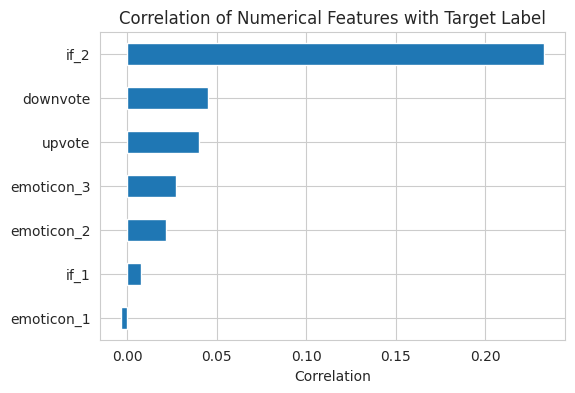

In [48]:
corr_with_target = train[num_cols + ['label']].corr()['label'].drop('label')

plt.figure(figsize=(6,4))
corr_with_target.sort_values().plot(kind='barh')

plt.title("Correlation of Numerical Features with Target Label")
plt.xlabel("Correlation")

plt.show()

# Insight: Correlation of Numerical Features with Target

* The bar chart illustrates the correlation between numerical features and the target label.

* Among all numerical features, if_2 shows the strongest correlation with the target variable (~0.23), suggesting that it may contain useful information for distinguishing between comment categories.

* Other engagement-related features such as upvote and downvote exhibit relatively weak correlations with the label, indicating limited predictive power when used individually.

* The emoticon-related features show minimal correlation, suggesting that emoticon usage alone does not strongly determine the comment category.

* Overall, most numerical features display low correlation with the target, indicating that the classification task likely depends more heavily on the textual content of the comments rather than numerical metadata alone.

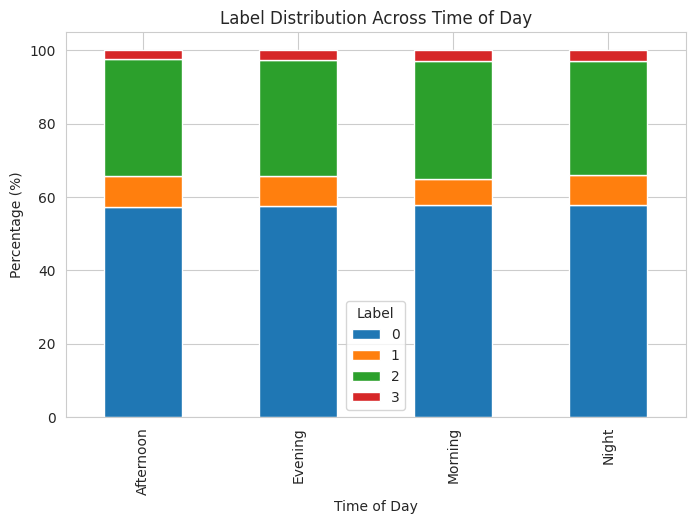

In [49]:
train['created_date'] = pd.to_datetime(train['created_date'])

train['hour'] = train['created_date'].dt.hour

def get_time_bucket(hour):
    if 0 <= hour < 6:
        return 'Night'
    elif 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 18:
        return 'Afternoon'
    else:
        return 'Evening'

train['time_bucket'] = train['hour'].apply(get_time_bucket)

time_label_dist = pd.crosstab(train['time_bucket'], train['label'], normalize='index') * 100

time_label_dist

time_label_dist.plot(kind='bar', stacked=True, figsize=(8,5))

plt.title("Label Distribution Across Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Percentage (%)")

plt.legend(title='Label')
plt.show()

Overall, this analysis suggests that temporal features such as time of day contribute minimally to classification, and the model is likely to rely more on textual features and interaction signals for prediction.

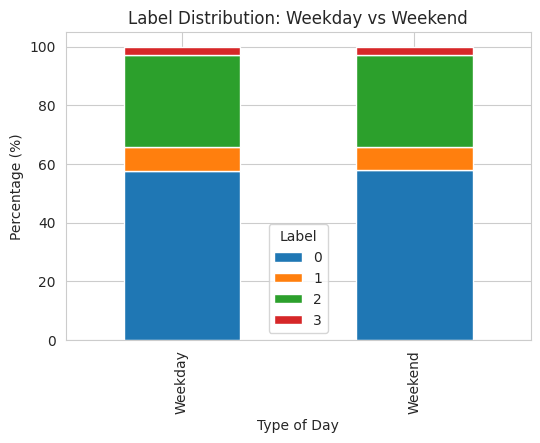

In [50]:
train['dayofweek'] = train['created_date'].dt.dayofweek

train['is_weekend'] = train['dayofweek'].apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

week_dist = pd.crosstab(train['is_weekend'], train['label'], normalize='index') * 100
week_dist

week_dist.plot(kind='bar', stacked=True, figsize=(6,4))

plt.title("Label Distribution: Weekday vs Weekend")
plt.xlabel("Type of Day")
plt.ylabel("Percentage (%)")

plt.legend(title='Label')
plt.show()

The distribution of labels is almost identical for both weekdays and weekends, indicating that the type of day has minimal influence on comment categories. Overall, this analysis indicates that weekend vs weekday does not significantly impact the classification of comments, and thus temporal features like day type provide limited predictive value compared to textual features.

# Feature Engineering

After performing EDA, the next step is to prepare the dataset for ML models. Feature engineering involves transforming raw data into meaningful numerical representations that models can effectively learn from.

In this project, both textual features and numerical metadata are utilized. The comment text is transformed using TF-IDF vectorization, while numerical features such as engagement metrics and emoticon indicators are standardized to ensure consistent scaling.

These transformations allow the model to capture both semantic information from text and additional contextual signals from metadata features.

# Text Cleaning or Preprocessing

Before converting comments into numerical features, basic text cleaning is performed. This includes converting text to lowercase, removing URLs, removing non-alphabetic characters, and normalizing whitespace.

This helps reduce noise in the textual data and ensures that the vectorization process focuses on meaningful tokens.

In [51]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-z ]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

train['comment'] = train['comment'].fillna('')
test['comment'] = test['comment'].fillna('')

train['clean_comment'] = train['comment'].apply(clean_text)
test['clean_comment'] = test['comment'].apply(clean_text)



# TF-IDF Feature Extraction - 

To convert textual comments into numerical form, TF-IDF (Term Frequency–Inverse Document Frequency) vectorization is applied. TF-IDF assigns higher importance to words that appear frequently in a comment but are relatively rare across the entire dataset.

This allows the model to focus on informative words while reducing the influence of very common terms.

In [52]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1,2),   
    min_df=3,
    max_df=0.95,
    sublinear_tf=True
)

X_text = tfidf.fit_transform(train['clean_comment'])
X_text_test = tfidf.transform(test['clean_comment'])

max_features=8000 - limits vocabulary to 8,000 most important terms.

ngram_range=(1,2) - includes both individual words (unigrams) and pairs of words (bigrams)

min_df=3 - ignores words that appear in fewer than 3 documents

max_df=0.95 - ignores words that appear in more than 95% of documents (too common)

sublinear_tf=True - applies log(1+tf) to smooth term frequency values. basically it is a setting that helps prevent long documents from unfairly dominating over short documents just because they have more words.


# Numerical Feature Selection - 

In addition to textual features, several numerical features are included in the model. These features capture engagement signals and symbolic expressions within comments.

In [53]:
num_features = [
    'emoticon_1','emoticon_2','emoticon_3',
    'upvote','downvote','if_1','if_2',
    'disability','comment_length'
]

# Feature Scaling

Numerical features are standardized using StandardScaler to ensure that all features have comparable scales. This helps prevent features with large values from dominating the model.

In [54]:
# create comment length feature for test set
test['comment_length'] = test['comment'].fillna('').apply(len)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_num = scaler.fit_transform(train[num_features])
X_num_test = scaler.transform(test[num_features])

I applied StandardScaler to standardize numerical features so they all have mean 0 and standard deviation 1. This prevents large-valued features from dominating.

# Combining Text and Numerical Features

Finally, the TF-IDF text features and numerical features are combined into a single feature matrix. This allows the model to learn from both textual content and metadata simultaneously.

In [55]:
from scipy.sparse import hstack

X = hstack([X_text, X_num])
X_test_final = hstack([X_text_test, X_num_test])

y = train['label']

I used hstack from scipy.sparse to horizontally concatenate the TF-IDF sparse matrix and the numerical feature matrix.
Simply it joins data horizontally side by side. 

A = [[1], [2], [3]]
B = [[4], [5], [6]]

After hstack:

[[1, 4],
 [2, 5],
 [3, 6]]

# Model Training

To evaluate the effectiveness of the engineered features, multiple machine learning models are trained and compared. The goal is to determine how well different algorithms can learn patterns from the combined textual TF-IDF features and numerical metadata features.

The following models are explored:

* Logistic Regression

* Multinomial Naive Bayes

* LightGBM (Final Model)

Each model is evaluated using a validation split of the training dataset.

In [56]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X contains the features and y contains the target labels.

test_size=0.2 to allocate 20% of the data for validation and 80% for training.

The stratify=y parameter ensures that the class distribution remains the same in both training and validation sets.

random_state=42 is used to make the split reproducible, meaning the same split will be generated every time the code is run.

🔹 Logistic Regression

Logistic Regression was used as a baseline model. It performs well on high-dimensional sparse data such as TF-IDF vectors and provides fast and interpretable results.

🔹 Naive Bayes

Naive Bayes is well-suited for text classification tasks. It is based on probabilistic principles and works efficiently with word frequency features, making it a strong choice for NLP problems.

🔹 LightGBM

LightGBM is an advanced gradient boosting model that can capture complex and non-linear relationships in the data. It is efficient and often provides better performance compared to simpler models.

Using these three models allows for a comprehensive comparison:

Logistic Regression - strong baseline

Naive Bayes - optimized for text data

LightGBM - handles complex patterns

This approach ensures robust model selection and better understanding of model performance.

In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

log_preds = log_model.predict(X_val)

log_acc = accuracy_score(y_val, log_preds)

print("Logistic Regression Accuracy:", log_acc)

Logistic Regression Accuracy: 0.9016919191919192


Imported the model and evaluation metric.

Then I initialized the Logistic Regression model with max_iter=1000 to ensure proper convergence.

I trained the model using the training data with the fit method.

After training, I used the model to predict labels for the validation set.

Finally, I evaluated the model using accuracy score by comparing predicted labels with actual labels.

- Validation Accuracy: 90.17%

In [58]:
# Train-validation split for text features only
X_train_text, X_val_text, y_train, y_val = train_test_split(
    X_text,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

nb_model = MultinomialNB()

nb_model.fit(X_train_text, y_train)

nb_preds = nb_model.predict(X_val_text)

nb_acc = accuracy_score(y_val, nb_preds)

print("Naive Bayes Accuracy:", nb_acc)

Naive Bayes Accuracy: 0.6963383838383839


Score is less because it assumes that features or columns are independent and they don't have correlation between them. In our data textual features are there and there is a little bit correlation as well, i think because of that the accuracy is less.

Trained and evaluated a Multinomial Naive Bayes model using only the TF-IDF text features.

Split the text feature matrix into training and validation sets while maintaining class distribution using stratified sampling.

Then, I initialized the Multinomial Naive Bayes model and trained it on the training data.

After training, I predicted labels for the validation set and evaluated the model using accuracy score.

Validation Accuracy:69.63%


In [59]:
import lightgbm as lgb

lgb_model = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=4,
    n_estimators=300,
    learning_rate=0.08,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgb_model.fit(X_train, y_train)

lgb_preds = lgb_model.predict(X_val)

lgb_acc = accuracy_score(y_val, lgb_preds)

print("LightGBM Accuracy:", lgb_acc)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 7.575482 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1105673
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 8009
[LightGBM] [Info] Start training from score -0.550557
[LightGBM] [Info] Start training from score -2.520769
[LightGBM] [Info] Start training from score -1.154061
[LightGBM] [Info] Start training from score -3.589217


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM Accuracy: 0.9118686868686868


A gradient boosting model that builds an ensemble of decision trees iteratively, where each tree corrects the errors of the previous one.

Configured LightGBM with:

objective='multiclass for 4-class classification,

n_estimators=300 - 300 boosting rounds.
Number of trees (boosting iterations).
More trees = better learning (but slower).

learning_rate=0.08 - moderate step size.
Controls how fast the model learns.
Smaller - more stable learning.
Larger - faster but risk of overfitting.

num_leaves=64 - controls tree complexity.
Controls complexity of each tree.
More leaves - more complex model.

subsample=0.8 - uses 80% of rows per tree.
Uses 80% of data for each tree.
Helps reduce overfitting.

colsample_bytree=0.8 - uses 80% of features per tree.
Adds randomness - better generalization.

In [60]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "LightGBM"
    ],
    "Accuracy": [
        log_acc,
        nb_acc,
        lgb_acc
    ]
})

results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
2,LightGBM,0.911869
0,Logistic Regression,0.901692
1,Naive Bayes,0.696338


# Model Performance Comparison

The validation results show clear differences in performance across the three models.

* LightGBM achieves the highest accuracy (0.911), indicating its ability to capture complex relationships between textual and numerical features.

* Logistic Regression also performs strongly (0.900), which is expected for high-dimensional TF-IDF text representations.

* Multinomial Naive Bayes achieves lower accuracy (0.696), as it relies on simplifying assumptions and uses only textual features.

Overall, these results suggest that combining textual features with additional numerical metadata provides better predictive performance.

Based on validation performance, LightGBM is selected as the final model for generating predictions on the test dataset.

# Final Model Selection

Based on the validation results obtained during model comparison, LightGBM achieved the highest accuracy among all evaluated models. Therefore, LightGBM is selected as the final model for generating predictions on the test dataset.

To maximize the training data available for the model, the final LightGBM classifier is trained using the entire training dataset before generating predictions for the test set.

**We used RandomizedSearchCV to find the best hyperparameters for the LightGBM model.**

Tried 15 random combinations.

Used 3-fold cross-validation for reliable evaluation.

Tuned key parameters like n_estimators, learning_rate, num_leaves, subsample, and colsample_bytree.

Best Parameters
{'subsample': 0.9, 
 'num_leaves': 50, 
 'n_estimators': 500, 
 'learning_rate': 0.05, 
 'colsample_bytree': 0.8}

**Insights**
 - More trees (n_estimators=500) improved performance
- Lower learning rate (0.05) gave stable learning
- Moderate num_leaves avoided overfitting
- Feature & row sampling helped generalization

In [61]:
lgb_model = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=4,
    random_state=42
)

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.08, 0.1],
    "num_leaves": [31, 50, 64, 100],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9]
}

random_search = RandomizedSearchCV(
    estimator=lgb_model,
    param_distributions=param_dist,
    n_iter=15,          # try 15 combos
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1 
)

random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_
val_preds = best_model.predict(X_val)
final_model = random_search.best_estimator_
final_model.fit(X, y)
print("Best Parameters:", random_search.best_params_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 15.020261 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 850998
[LightGBM] [Info] Number of data points in the train set: 105600, number of used features: 8009
[LightGBM] [Info] Start training from score -0.550557
[LightGBM] [Info] Start training from score -2.520769
[LightGBM] [Info] Start training from score -1.154071
[LightGBM] [Info] Start training from score -3.589103
[CV] END colsample_bytree=0.7, learning_rate=0.08, n_estimators=200, num_leaves=100, subsample=0.8; total time=23.9min
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 22.882888 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 848423
[LightGBM] [Info] Number of data points in the train set: 105600, number of used features: 8009
[LightGBM] 

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 15.000065 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 850998
[LightGBM] [Info] Number of data points in the train set: 105600, number of used features: 8009
[LightGBM] [Info] Start training from score -0.550557
[LightGBM] [Info] Start training from score -2.520769
[LightGBM] [Info] Start training from score -1.154071
[LightGBM] [Info] Start training from score -3.589103
[CV] END colsample_bytree=0.8, learning_rate=0.01, n_estimators=500, num_leaves=64, subsample=0.7; total time=45.9min
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 16.425048 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 851110
[LightGBM] [Info] Number of data points in the train set: 105600, number of used features: 8009
[LightGBM] [Info] Start training from score -0.550557
[LightGBM] [Info] Star

...

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 16.579293 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 848423
[LightGBM] [Info] Number of data points in the train set: 105600, number of used features: 8009
[LightGBM] [Info] Start training from score -0.550557
[LightGBM] [Info] Start training from score -2.520769
[LightGBM] [Info] Start training from score -1.154071
[LightGBM] [Info] Start training from score -3.589103
[CV] END colsample_bytree=0.7, learning_rate=0.01, n_estimators=300, num_leaves=50, subsample=0.9; total time=21.7min
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 15.258128 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 848423
[LightGBM] [Info] Number of data points in t

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 7.884154 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1105673
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 8009
[LightGBM] [Info] Start training from score -0.550557
[LightGBM] [Info] Start training from score -2.520769
[LightGBM] [Info] Start training from score -1.154061
[LightGBM] [Info] Start training from score -3.589217
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 20.405722 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 850998
[LightGBM] [Info] Number of data points in the train set: 105600, number of used features: 8009
[LightGBM] [Info] Start training from score -0.550557
[LightGBM] [Info] Start training from score -2.520769
[LightGBM] [Info] Start training from score -1.154071
[LightGBM] [Info] Start training

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 9.916724 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1263099
[LightGBM] [Info] Number of data points in the train set: 198000, number of used features: 8009
[LightGBM] [Info] Start training from score -0.550552
[LightGBM] [Info] Start training from score -2.520816
[LightGBM] [Info] Start training from score -1.154061
[LightGBM] [Info] Start training from score -3.589171
Best Parameters: {'subsample': 0.9, 'num_leaves': 50, 'n_estimators': 500, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


The model is trained on the complete training dataset to utilize all available information for learning the classification patterns.

In [64]:
test_preds = final_model.predict(X_test_final)

try:
    submission = pd.read_csv(f'{DATA_PATH}/sample_submission.csv')
except:
    submission = pd.read_csv(f'{DATA_PATH}/Sample.csv')

submission['label'] = test_preds
submission.to_csv('/kaggle/working/submission.csv', index=False)

print("Submission file created")
print(os.listdir('/kaggle/working'))

submission.head()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")


Submission file created
['submission.csv', '.virtual_documents']


,ID,label
0,1,2
1,2,2
2,3,0
3,4,0
4,5,2


# OVERALL SUMMARY-

- The task was to classify user comments into 4 categories using textual and numerical data.
- The major challenge was the severe class imbalance and 73% missing demographic data.
- I handled missing comments with empty string filling and excluded unmeaningful missing columns.
- Text was cleaned and transformed with TF-IDF.
- Numerical features were standardized and combined with TF-IDF.
- LightGBM outperformed Logistic Regression and Naive Bayes with - 91.2% validation accuracy.
- Hyperparameter tuning using RandomizedSearchCV was applied to optimize model performance.
- The final model was trained on all 198,000 training samples to generate test predictions.